Title: Temperature Forecasting using Prophet

install prophet

In [1]:
!pip install prophet

import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

load dataset

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


re name columns

In [4]:
df.columns = ['ds', 'y']

df.head()

,ds,y
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


create model

In [6]:
model = Prophet()

model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


future dates

In [7]:
future = model.make_future_dataframe(
    periods=365
)

future.tail()

,ds
4010,1991-12-27
4011,1991-12-28
4012,1991-12-29
4013,1991-12-30
4014,1991-12-31


forecast

In [8]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1981-01-01,11.845440,11.572380,18.706361,11.845440,11.845440,3.328364,3.328364,3.328364,0.010971,0.010971,0.010971,3.317392,3.317392,3.317392,0.0,0.0,0.0,15.173804
1,1981-01-02,11.843589,11.847973,18.601112,11.843589,11.843589,3.375355,3.375355,3.375355,-0.019836,-0.019836,-0.019836,3.395191,3.395191,3.395191,0.0,0.0,0.0,15.218944
2,1981-01-03,11.841738,12.009451,18.804183,11.841738,11.841738,3.412352,3.412352,3.412352,-0.060155,-0.060155,-0.060155,3.472507,3.472507,3.472507,0.0,0.0,0.0,15.254090
3,1981-01-04,11.839888,11.769810,18.615484,11.839888,11.839888,3.394990,3.394990,3.394990,-0.153103,-0.153103,-0.153103,3.548093,3.548093,3.548093,0.0,0.0,0.0,15.234878
4,1981-01-05,11.838037,11.951026,18.985925,11.838037,11.838037,3.601005,3.601005,3.601005,-0.019721,-0.019721,-0.019721,3.620726,3.620726,3.620726,0.0,0.0,0.0,15.439042


plot forecast

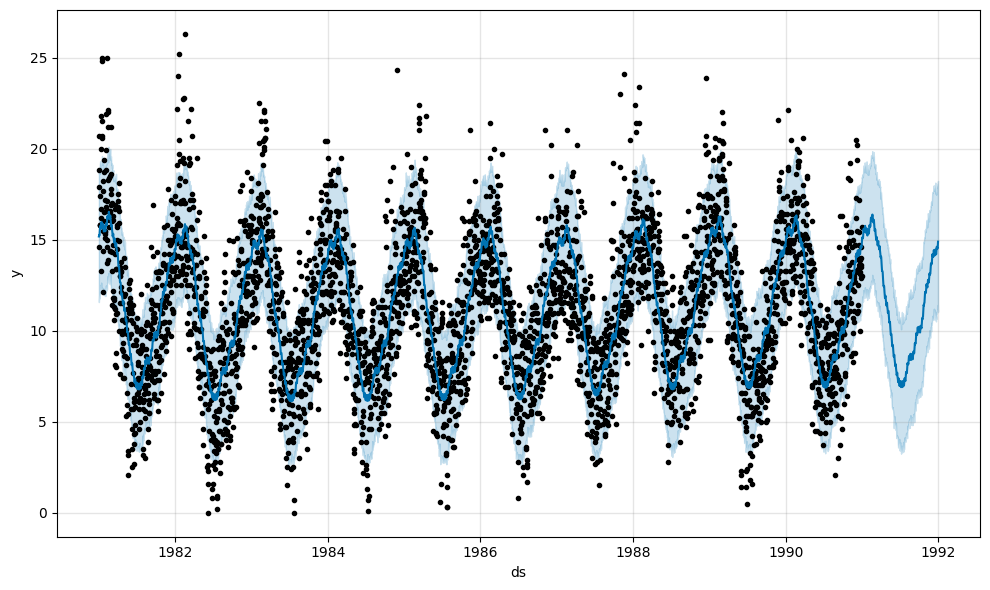

In [9]:
fig = model.plot(forecast)

plt.show()

components plot

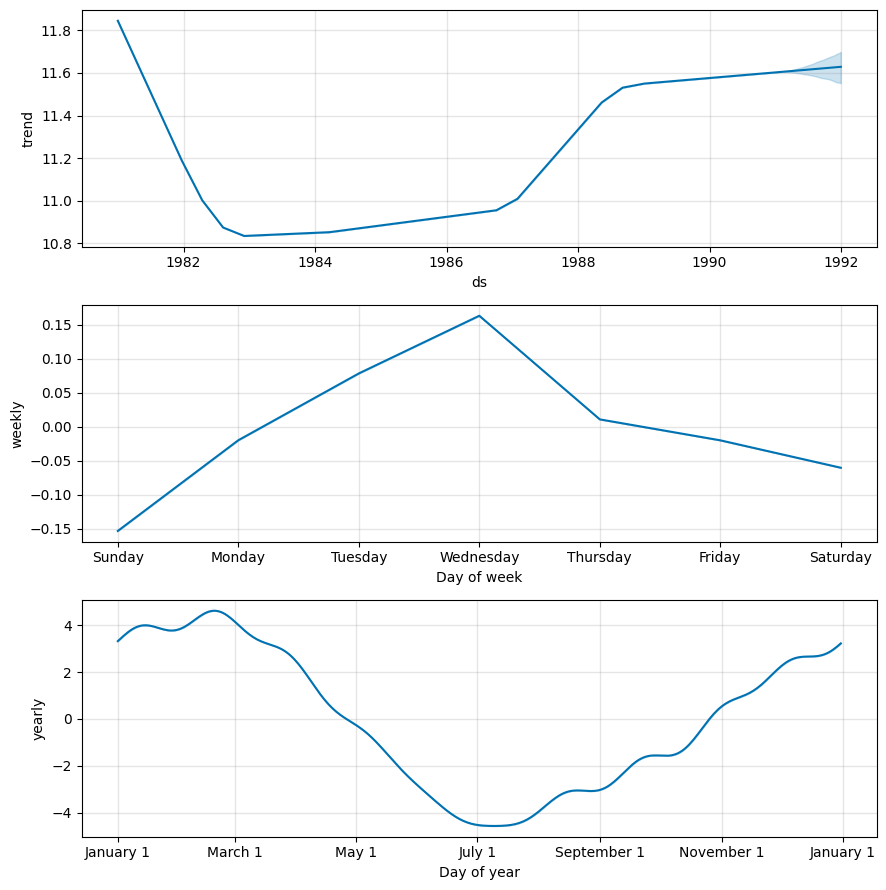

In [10]:
fig2 = model.plot_components(
    forecast
)

plt.show()